In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install -q "transformers==4.35.2" "accelerate==0.26.1" "peft==0.7.1" --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.9/270.9 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.35.2 which is incompatible.


In [ ]:
!pip install -q transformers==4.35.2 accelerate==0.26.1 peft==0.7.1 --upgrade

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

spam_email_dataset.csv:   0%|          | 0.00/112M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/85782 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text_combined', 'label'],
        num_rows: 85782
    })
})
Dataset loaded: 85782 samples
Class distribution:
label
0    42891
1    42891
Name: count, dtype: int64



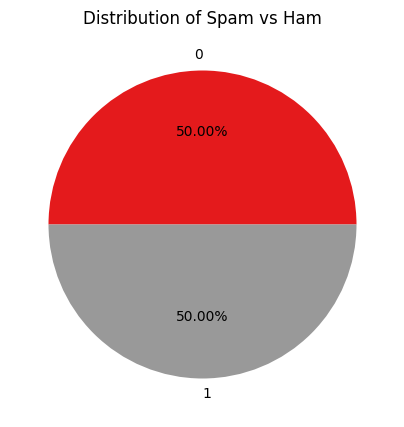

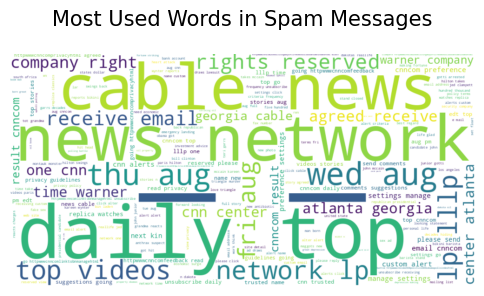

Normalization complete: 85777 samples remaining
 Train set: 60043 samples
  - Ham: 30023, Spam: 30020
 Validation set: 8578 samples
  - Ham: 4289, Spam: 4289
 Test set: 17156 samples
  - Ham: 8579, Spam: 8577


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

DatasetDict({
    train: Dataset({
        features: ['__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 60043
    })
    validation: Dataset({
        features: ['__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 8578
    })
    test: Dataset({
        features: ['__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 17156
    })
})


Saving the dataset (0/1 shards):   0%|          | 0/60043 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8578 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/17156 [00:00<?, ? examples/s]

Saved to Drive: /content/drive/MyDrive/distilbert_spam_optuna


In [ ]:
# -*- coding: utf-8 -*-
"""Preprocessing.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1ZRAPMYH61qKE4p1Nv3pBI6N2awlUOS3T

**Libraries**
"""

# Commented out IPython magic to ensure Python compatibility.
#Libraries
import numpy as np
import pandas as pd
import re

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Word Cloud library
from wordcloud import WordCloud, STOPWORDS

# Library used for data preprocessing
from datasets import load_dataset, DatasetDict, Dataset, ClassLabel
from transformers import AutoTokenizer

# Model selection libraries
from sklearn.model_selection import train_test_split

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
# %matplotlib inline

import os

# Define folder structure
base_dir = os.getcwd()  # current directory
data_dir = os.path.join(base_dir, "data")
models_dir = os.path.join(base_dir, "models")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

"""**Dataset Loading**"""

dataset = load_dataset("bourigue/data_email_spam")
print(dataset)

df = dataset['train'].to_pandas()
df.head()

print(f"Dataset loaded: {len(df)} samples")
print(f"Class distribution:\n{df['label'].value_counts()}\n")

"""**Dataset Visualization**"""

import matplotlib.pyplot as plt

# Label distribution
spread = df['label'].value_counts()

# Pie chart
plt.rcParams['figure.figsize'] = (5, 5)
spread.plot(kind='pie', autopct='%1.2f%%', cmap='Set1')
plt.title('Distribution of Spam vs Ham')
plt.ylabel('')
plt.show()

"""Word Cloud Visualization:"""

df_spam = df[df['label'] == 1]
stopwords = set(STOPWORDS)
text = " ".join(df_spam['text_combined'].astype(str).tolist()).lower()

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords,
    max_words=1000
).generate(text)

plt.figure(figsize=(6, 6))
plt.title("Most Used Words in Spam Messages", fontsize=15, pad=20)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

"""**Preprocessing Dataset**"""

CONFIG = {
    'model_name': 'distilbert-base-uncased',
    'max_length': 128,
    'train_split': 0.7,
    'val_split': 0.1,
    'test_split': 0.2,
    'seed': 42
}

# Normalization:

def normalize_text(text):
    #Normalizing and cleaning email text while preserving spam indicators

    if pd.isna(text):
        return ""

    text = str(text)

    #Lowercase
    text = text.lower()

    #Normalize repeated characters (such as "oooo " or "eeeee")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    #Normalize numbers and replace with NUMBER token
    text = re.sub(r'\d+', ' NUMBER ', text)

    #Normalize currency symbols
    text = re.sub(r'[$£€¥₹]', ' CURRENCY ', text)

    #Replace URLs with URL token
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)

    #Replace email addresses with EMAIL token
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)

    #Normalize excessive punctuation
    text = re.sub(r'!{2,}', ' EXCLAMATION ', text)
    text = re.sub(r'\?{2,}', ' QUESTION ', text)

    #Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    #Remove special characters
    text = re.sub(r'[^\w\s!?$]', ' ', text)

    #Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    #Remove very short texts
    if len(text) < 10:
        return ""

    return text

df['text_combined'] = df['text_combined'].apply(normalize_text)

# Remove empty texts after normalization
df = df[df['text_combined'].str.len() > 0].reset_index(drop=True)
print(f"Normalization complete: {len(df)} samples remaining")

## save the cleaned dataset (for TF-IDF models) !!! put in gitignore
cleaned_path = os.path.join(data_dir, "cleaned_spam_dataset.csv")
df.to_csv(cleaned_path, index=False)

"""**Splitting dataset**"""

#Test set:
train_val_df, test_df = train_test_split(
    df,
    test_size=CONFIG['test_split'],
    random_state=CONFIG['seed'],
    stratify=df['label']
)

#Validation set from training set:
val_size = CONFIG['val_split'] / (CONFIG['train_split'] + CONFIG['val_split'])
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_size,
    random_state=CONFIG['seed'],
    stratify=train_val_df['label']
)

print(f" Train set: {len(train_df)} samples")
print(f"  - Ham: {(train_df['label']==0).sum()}, Spam: {(train_df['label']==1).sum()}")
print(f" Validation set: {len(val_df)} samples")
print(f"  - Ham: {(val_df['label']==0).sum()}, Spam: {(val_df['label']==1).sum()}")
print(f" Test set: {len(test_df)} samples")
print(f"  - Ham: {(test_df['label']==0).sum()}, Spam: {(test_df['label']==1).sum()}")

## save individual splits for consistency
train_path = os.path.join(data_dir, "train_split.csv")
val_path   = os.path.join(data_dir, "val_split.csv")
test_path  = os.path.join(data_dir, "test_split.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

"""**Tokenization**"""

def tokenize_function(examples):

    tokens = tokenizer(
        examples['text_combined'],
        max_length=CONFIG['max_length'],
        padding='max_length',
        truncation=True,
        return_attention_mask=True
    )
    tokens['labels'] = examples['label']
    return tokens

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

train_dataset = Dataset.from_pandas(train_df[['text_combined', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text_combined', 'label']])
test_dataset = Dataset.from_pandas(test_df[['text_combined', 'label']])

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=['text_combined', 'label'])
tokenized_val = val_dataset.map(tokenize_function, batched=True, remove_columns=['text_combined', 'label'])
tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=['text_combined', 'label'])

#Final Dataset:
final_dataset = DatasetDict({'train': tokenized_train, 'validation': tokenized_val,'test': tokenized_test})

print(final_dataset)

## Save the tokenized dataset (for transformers)
tokenized_path = "/content/drive/MyDrive/distilbert_spam_optuna"
final_dataset.save_to_disk(tokenized_path)
print("Saved to Drive:", tokenized_path)

In [ ]:
import torch

from datasets import load_from_disk
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_callback import TrainerCallback

warnings.filterwarnings("ignore")

DRIVE_ROOT   = "/content/drive/MyDrive/Spam_DistilBERT_Project"

DATA_DIR     = "/content/drive/MyDrive/distilbert_spam_optuna"

MODEL_DIR    = os.path.join(DRIVE_ROOT, "models")
LOG_DIR      = os.path.join(DRIVE_ROOT, "logs")
PLOT_DIR     = os.path.join(DRIVE_ROOT, "plots")
RESULTS_DIR  = os.path.join(DRIVE_ROOT, "results")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")

for d in [MODEL_DIR, LOG_DIR, PLOT_DIR, RESULTS_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)

class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.train_steps, self.train_losses = [], []
        self.eval_steps, self.eval_losses, self.eval_accs = [], [], []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        if "loss" in logs:
            self.train_steps.append(state.global_step)
            self.train_losses.append(logs["loss"])
        if "eval_loss" in logs:
            self.eval_steps.append(state.global_step)
            self.eval_losses.append(logs["eval_loss"])
        if "eval_accuracy" in logs:
            self.eval_accs.append(logs["eval_accuracy"])

ds = load_from_disk(DATA_DIR)
ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print("Splits:", list(ds.keys()))   # should show ['train', 'validation', 'test']

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    overwrite_output_dir=True,
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir=LOG_DIR,
    logging_steps=100,
    evaluation_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    load_best_model_at_end=False,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    report_to="none",
)

metrics_cb = MetricsCallback()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[metrics_cb],
)

print("Training DistilBERT")
trainer.train()

print("Evaluating on test set")
results = trainer.evaluate(ds["test"])
for k, v in results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

pd.DataFrame([results]).to_csv(
    os.path.join(RESULTS_DIR, "distilbert_results.csv"),
    index=False,
)

train_df = pd.DataFrame({
    "step": metrics_cb.train_steps,
    "loss": metrics_cb.train_losses,
})
eval_df = pd.DataFrame({
    "step": metrics_cb.eval_steps,
    "loss": metrics_cb.eval_losses,
    "accuracy": metrics_cb.eval_accs,
})
train_df.to_csv(
    os.path.join(RESULTS_DIR, "distilbert_train_loss_history.csv"),
    index=False,
)
eval_df.to_csv(
    os.path.join(RESULTS_DIR, "distilbert_eval_loss_history.csv"),
    index=False,
)

if metrics_cb.train_losses:
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(
        metrics_cb.train_steps,
        metrics_cb.train_losses,
        label="Train Loss",
        color="tab:blue",
    )
    if metrics_cb.eval_losses:
        ax1.plot(
            metrics_cb.eval_steps,
            metrics_cb.eval_losses,
            label="Val Loss",
            color="tab:orange",
            marker="o",
        )
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    if metrics_cb.eval_accs:
        ax2 = ax1.twinx()
        ax2.plot(
            metrics_cb.eval_steps,
            metrics_cb.eval_accs,
            label="Val Accuracy",
            color="tab:green",
            marker="s",
        )
        ax2.set_ylabel("Accuracy", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")
        ax2.legend(loc="upper right")

    plt.title("DistilBERT Training Progress")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOT_DIR, "distilbert_training_curve.png"),
        dpi=300,
    )
    plt.close()
else:
    print("No metrics recorded.")

Splits: ['train', 'validation', 'test']


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training DistilBERT


You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
200,0.122300,0.093847,0.967358,0.952994,0.983213,0.967868
400,0.093400,0.059958,0.977501,0.974954,0.980182,0.977561
600,0.060400,0.056073,0.983679,0.974388,0.993472,0.983837
800,0.060400,0.047196,0.985078,0.989414,0.980648,0.985012
1000,0.042300,0.039655,0.988342,0.990630,0.986011,0.988315
1200,0.049700,0.047819,0.984262,0.992647,0.975752,0.984127
1400,0.059400,0.064371,0.977384,0.996123,0.958498,0.976949
1600,0.039000,0.035396,0.990091,0.993659,0.986477,0.990055
1800,0.041200,0.026700,0.992073,0.992992,0.991140,0.992065
2000,0.014800,0.033419,0.991840,0.996003,0.987643,0.991805


You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with 

Evaluating on test set


You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


eval_loss: 0.0329
eval_accuracy: 0.9914
eval_precision: 0.9929
eval_recall: 0.9900
eval_f1: 0.9914
eval_runtime: 18.4768
eval_samples_per_second: 928.5170
eval_steps_per_second: 14.5590
epoch: 2.0000


In [ ]:
!pip install optuna
!pip install optuna-integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.9 MB/s eta 0:00:00


In [ ]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)
from transformers.trainer_callback import TrainerCallback
from datasets import load_from_disk

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1) Base paths (use Google Drive if available)
# ------------------------------------------------------------
try:
    BASE_DIR = "/content/drive/MyDrive/distilbert_spam_optuna"
    print("Using Google Drive base dir:", BASE_DIR)
except ImportError:
    BASE_DIR = os.getcwd()

# THIS IS THE CORRECT PATH
DATA_DIR = BASE_DIR

MODEL_DIR  = os.path.join(BASE_DIR, "models", "final_distilbert_spam_classifier")
LOG_DIR    = os.path.join(BASE_DIR, "logs")
PLOT_DIR   = os.path.join(BASE_DIR, "plots")
OPTUNA_DIR = os.path.join(PLOT_DIR, "optuna")
OPTUNA_DB  = os.path.join(BASE_DIR, "optuna_distilbert_spam.db")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(OPTUNA_DIR, exist_ok=True)
os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)

# incremental CSV to log each trial as soon as it's done
TRIALS_CSV = os.path.join(OPTUNA_DIR, "optuna_trials_incremental.csv")

# total trials (overall)
N_TARGET_TRIALS = 8

set_seed(42)

Using Google Drive base dir: /content/drive/MyDrive/distilbert_spam_optuna


In [ ]:
class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.train_steps, self.train_losses = [], []
        self.eval_steps,  self.eval_losses  = [], []
        self.metric_steps = []
        self.eval_accuracy = []
        self.eval_f1 = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        if "loss" in logs:
            self.train_steps.append(state.global_step)
            self.train_losses.append(logs["loss"])

        if "eval_loss" in logs:
            self.eval_steps.append(state.global_step)
            self.eval_losses.append(logs["eval_loss"])

        if "eval_accuracy" in logs:
            self.metric_steps.append(state.global_step)
            self.eval_accuracy.append(logs["eval_accuracy"])

        if "eval_f1" in logs:
            self.eval_f1.append(logs["eval_f1"])

# ------------------------------------------------------------
# 3) Load dataset & tokenizer
# ------------------------------------------------------------
print("Loading dataset from:", DATA_DIR)
dataset = load_from_disk(DATA_DIR)
dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_ds = dataset["train"]
val_ds   = dataset["validation"]
test_ds  = dataset["test"]

print("Loading tokenizer...")
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

Loading dataset from: /content/drive/MyDrive/distilbert_spam_optuna
Loading tokenizer...


In [ ]:
!ls -R "/content/drive/MyDrive/distilbert_spam_optuna"

/content/drive/MyDrive/distilbert_spam_optuna:
dataset_dict.json  logs  models  plots	test  train  validation

/content/drive/MyDrive/distilbert_spam_optuna/logs:

/content/drive/MyDrive/distilbert_spam_optuna/models:
final_distilbert_spam_classifier

/content/drive/MyDrive/distilbert_spam_optuna/models/final_distilbert_spam_classifier:

/content/drive/MyDrive/distilbert_spam_optuna/plots:
optuna

/content/drive/MyDrive/distilbert_spam_optuna/plots/optuna:

/content/drive/MyDrive/distilbert_spam_optuna/test:
data-00000-of-00001.arrow  dataset_info.json  state.json

/content/drive/MyDrive/distilbert_spam_optuna/train:
data-00000-of-00001.arrow  dataset_info.json  state.json

/content/drive/MyDrive/distilbert_spam_optuna/validation:
data-00000-of-00001.arrow  dataset_info.json  state.json


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [ ]:
def log_trial_result(trial, eval_result, lr, wd, epochs, bsz, drop):
    row = {
        "trial_number": trial.number,
        "learning_rate": lr,
        "weight_decay": wd,
        "num_train_epochs": epochs,
        "per_device_train_batch_size": bsz,
        "dropout": drop,
        "eval_loss": float(eval_result["eval_loss"]),
        "eval_accuracy": float(eval_result["eval_accuracy"]),
        "eval_precision": float(eval_result["eval_precision"]),
        "eval_recall": float(eval_result["eval_recall"]),
        "eval_f1": float(eval_result["eval_f1"]),
    }

    df = pd.DataFrame([row])
    file_exists = os.path.exists(TRIALS_CSV)

    df.to_csv(
        TRIALS_CSV,
        mode="a" if file_exists else "w",
        header=not file_exists,
        index=False,
    )

In [ ]:
def objective(trial: optuna.Trial) -> float:
    lr     = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    wd     = trial.suggest_float("weight_decay", 0.0, 0.1)
    epochs = trial.suggest_int("num_train_epochs", 2, 3)
    bsz    = trial.suggest_categorical("per_device_train_batch_size", [16, 32])
    drop   = trial.suggest_float("dropout", 0.1, 0.4)

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2,
    )

    # DistilBERT dropout config fields
    model.config.dropout = drop
    model.config.attention_dropout = drop

    out_dir = os.path.join(MODEL_DIR, "optuna_tmp", f"trial_{trial.number}")
    os.makedirs(out_dir, exist_ok=True)

    args = TrainingArguments(
        output_dir=out_dir,
        overwrite_output_dir=True,
        num_train_epochs=epochs,
        per_device_train_batch_size=bsz,
        per_device_eval_batch_size=64,
        learning_rate=lr,
        weight_decay=wd,
        evaluation_strategy="epoch",
        logging_strategy="no",
        save_strategy="no",
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()

    trainer.save_model(out_dir)

    trial.set_user_attr("eval_loss", float(eval_result["eval_loss"]))
    trial.set_user_attr("eval_accuracy", float(eval_result["eval_accuracy"]))
    trial.set_user_attr("eval_precision", float(eval_result["eval_precision"]))
    trial.set_user_attr("eval_recall", float(eval_result["eval_recall"]))
    trial.set_user_attr("eval_f1", float(eval_result["eval_f1"]))

    log_trial_result(trial, eval_result, lr, wd, epochs, bsz, drop)

    return eval_result["eval_f1"]

In [ ]:
print("\n=== Optuna hyperparameter search ===")

storage_url = f"sqlite:///{OPTUNA_DB}"
print("Optuna storage:", storage_url)

study = optuna.create_study(
    direction="maximize",
    study_name="distilbert_spam_optuna",
    storage=storage_url,
    load_if_exists=True,
)

n_existing = len(study.trials)
print(f"Existing trials in DB: {n_existing}")

n_to_run = max(0, N_TARGET_TRIALS - n_existing)
print(f"Target total trials: {N_TARGET_TRIALS} -> running {n_to_run} new trials")

if n_to_run > 0:
    study.optimize(objective, n_trials=n_to_run, show_progress_bar=True)
else:
    print("No new trials needed; already reached target number of trials.")

print("Best F1:", study.best_trial.value)
print("Best params:", study.best_trial.params)

study_df = study.trials_dataframe()
study_df.to_csv(os.path.join(OPTUNA_DIR, "optuna_trials_full_snapshot.csv"), index=False)

[I 2025-12-01 20:19:27,994] Using an existing study with name 'distilbert_spam_optuna' instead of creating a new one.



=== Optuna hyperparameter search ===
Optuna storage: sqlite:////content/drive/MyDrive/distilbert_spam_optuna/optuna_distilbert_spam.db
Existing trials in DB: 1
Target total trials: 8 -> running 7 new trials


  0%|          | 0/7 [00:00<?, ?it/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'classifier.bias', 'classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.031627,0.992073,0.993453,0.990674,0.992062
2,No log,0.031475,0.993588,0.992326,0.994871,0.993596


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.047101,0.987993,0.995267,0.980648,0.987904
2,No log,0.032995,0.993122,0.992777,0.993472,0.993124


[I 2025-12-01 21:17:42,108] Trial 6 finished with value: 0.9931243444819952 and parameters: {'learning_rate': 2.1138676056269367e-05, 'weight_decay': 0.025438095118702056, 'num_train_epochs': 2, 'per_device_train_batch_size': 16, 'dropout': 0.20075724475042284}. Best is trial 2 with value: 0.9951094550535631.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'classifier.bias', 'classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.033228,0.989625,0.990196,0.989042,0.989619
2,No log,0.032132,0.992539,0.991165,0.993938,0.992549


[I 2025-12-01 21:25:54,164] Trial 7 finished with value: 0.9925494761350407 and parameters: {'learning_rate': 1.169204471587665e-05, 'weight_decay': 0.026684053233000417, 'num_train_epochs': 2, 'per_device_train_batch_size': 32, 'dropout': 0.3514135959096739}. Best is trial 2 with value: 0.9951094550535631.
Best F1: 0.9951094550535631
Best params: {'learning_rate': 2.260427881737223e-05, 'weight_decay': 0.03191112853572673, 'num_train_epochs': 3, 'per_device_train_batch_size': 32, 'dropout': 0.27072173037801467}


In [ ]:
class MetricsTracker(TrainerCallback):
    def __init__(self):
        self.train_steps = []
        self.train_loss = []
        self.eval_steps = []
        self.eval_loss = []
        self.eval_accuracy = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.train_steps.append(state.global_step)
            self.train_loss.append(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self.eval_steps.append(state.global_step)
            self.eval_loss.append(metrics.get("eval_loss"))
            self.eval_accuracy.append(metrics.get("eval_accuracy"))


tracker = MetricsTracker()

best_params = study.best_trial.params
print("Using best params:", best_params)

from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
)

# Apply best dropout from Optuna
model.config.dropout = best_params["dropout"]
model.config.attention_dropout = best_params["dropout"]

best_training_args = TrainingArguments(
    output_dir=BEST_MODEL_DIR,
    overwrite_output_dir=True,

    # FIXED parameter names from Optuna
    num_train_epochs=best_params["num_train_epochs"],
    per_device_train_batch_size=best_params["per_device_train_batch_size"],

    per_device_eval_batch_size=64,
    learning_rate=best_params["learning_rate"],
    weight_decay=best_params["weight_decay"],

    logging_steps=100,
    eval_steps=200,
    evaluation_strategy="steps",
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none",
)

best_trainer = Trainer(
    model=model,
    args=best_training_args,
    train_dataset=train_ds,      # FIXED
    eval_dataset=val_ds,         # FIXED
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[tracker],
)

best_trainer.train()

# Save final best model
best_trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

# Evaluate on test set
test_metrics = best_trainer.evaluate(test_ds)
print("Test metrics:", test_metrics)

Using best params: {'learning_rate': 2.260427881737223e-05, 'weight_decay': 0.03191112853572673, 'num_train_epochs': 3, 'per_device_train_batch_size': 32, 'dropout': 0.27072173037801467}


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'classifier.bias', 'classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
200,0.125800,0.096766,0.967009,0.949708,0.986244,0.967631
400,0.089800,0.059994,0.980415,0.974879,0.986244,0.980529
600,0.062300,0.057707,0.982047,0.973871,0.990674,0.982201
800,0.057200,0.044124,0.986594,0.982878,0.990441,0.986645
1000,0.046000,0.041010,0.989275,0.986552,0.992073,0.989305
1200,0.051000,0.051978,0.984262,0.991249,0.977151,0.984149
1400,0.050700,0.037485,0.988459,0.995038,0.981814,0.988382
1600,0.047300,0.035995,0.989974,0.993194,0.986710,0.989942
1800,0.038100,0.035146,0.988692,0.995274,0.982047,0.988616
2000,0.015100,0.032419,0.992422,0.989569,0.995337,0.992444


Test metrics: {'eval_loss': 0.03504716232419014, 'eval_accuracy': 0.9930636512007461, 'eval_precision': 0.9934655775962661, 'eval_recall': 0.9926547743966422, 'eval_f1': 0.9930600104974631, 'eval_runtime': 18.9211, 'eval_samples_per_second': 906.713, 'eval_steps_per_second': 14.217, 'epoch': 3.0}


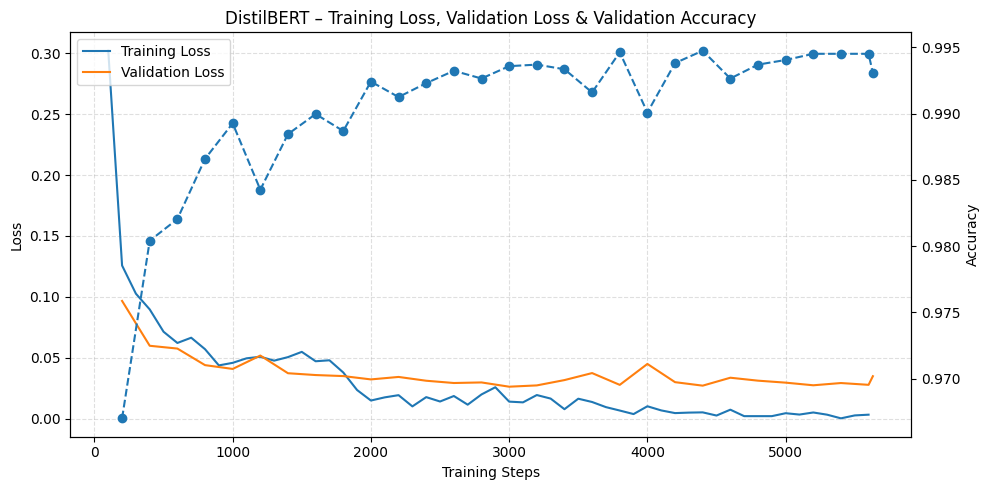

Saved training curve plot to: /content/gdrive/MyDrive/DistilBERT_data/plots/distilbert_training_curves.png


In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss curves
ax1.plot(tracker.train_steps, tracker.train_loss, label="Training Loss")
ax1.plot(tracker.eval_steps, tracker.eval_loss, label="Validation Loss")
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(loc="upper left")

# Validation accuracy curve (second y-axis)
ax2 = ax1.twinx()
ax2.plot(
    tracker.eval_steps,
    tracker.eval_accuracy,
    label="Validation Accuracy",
    marker="o",
    linestyle="--",
)
ax2.set_ylabel("Accuracy")

plt.title("DistilBERT – Training Loss, Validation Loss & Validation Accuracy")
plt.tight_layout()

# Save plot to Drive
plot_path = os.path.join(PLOTS_DIR, "distilbert_training_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()

print("Saved training curve plot to:", plot_path)

In [ ]:
fig_contour = viz.plot_contour(
    study,
    params=["learning_rate", "weight_decay", "batch_size", "num_epochs"],
)
fig_contour.show()

# Save the contour as HTML
contour_path = os.path.join(PLOTS_DIR, "optuna_contour.html")
fig_contour.write_html(contour_path)
print("Saved contour plot to:", contour_path)


ValueError: Parameter batch_size does not exist in your study.

In [ ]:
!pip install -U kaleido

In [ ]:
import plotly.io as pio
pio.kaleido.scope.default_format = "png"

AttributeError: 'NoneType' object has no attribute 'default_format'

In [ ]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances
)

print("Saving Optuna plots as HTML...")

hist_fig = plot_optimization_history(study)
hist_fig.update_layout(title="Optuna Optimization History (DistilBERT)")
hist_html = os.path.join(OPTUNA_DIR, "distilbert_optuna_history.html")
hist_fig.write_html(hist_html)
print("Saved:", hist_html)

imp_fig = plot_param_importances(study)
imp_fig.update_layout(title="Optuna Parameter Importances (DistilBERT)")
imp_html = os.path.join(OPTUNA_DIR, "distilbert_optuna_importances.html")
imp_fig.write_html(imp_html)
print("Saved:", imp_html)

Saving Optuna plots as HTML...
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_history.html
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_importances.html


In [ ]:
# ---- Test Evaluation ----
print("Evaluating on test set...")
test_results = best_trainer.evaluate(test_ds)

for k, v in test_results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")

# Save final model & tokenizer (already trained)
best_trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

# Save test metrics
pd.DataFrame([test_results]).to_csv(
    os.path.join(BEST_MODEL_DIR, "distilbert_test_results.csv"),
    index=False,
)

# ---------------------------------------------
# Save training curves (loss + accuracy)
# Using YOUR tracker
# ---------------------------------------------
train_loss_df = pd.DataFrame({
    "step": tracker.train_steps,
    "loss": tracker.train_loss
})

eval_loss_df = pd.DataFrame({
    "step": tracker.eval_steps,
    "loss": tracker.eval_loss
})

eval_acc_df = pd.DataFrame({
    "step": tracker.eval_steps,
    "eval_accuracy": tracker.eval_accuracy
})

# Save CSV files
train_loss_df.to_csv(os.path.join(BEST_MODEL_DIR, "train_loss_history.csv"), index=False)
eval_loss_df.to_csv(os.path.join(BEST_MODEL_DIR, "eval_loss_history.csv"), index=False)
eval_acc_df.to_csv(os.path.join(BEST_MODEL_DIR, "eval_accuracy_history.csv"), index=False)

print("\nSaved training curves & test metrics in:", BEST_MODEL_DIR)

Evaluating on test set...


eval_loss: 0.0350
eval_accuracy: 0.9931
eval_precision: 0.9935
eval_recall: 0.9927
eval_f1: 0.9931
eval_runtime: 19.6412
eval_samples_per_second: 873.4680
eval_steps_per_second: 13.6960
epoch: 3.0000

Saved training curves & test metrics in: /content/gdrive/MyDrive/DistilBERT_data/best_model


In [ ]:
plt.figure(figsize=(10, 5))

# Train loss
plt.plot(tracker.train_steps, tracker.train_loss,
         label="Train Loss", color="blue")

# Validation loss
plt.plot(tracker.eval_steps, tracker.eval_loss,
         label="Validation Loss", color="orange", marker="o")

plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.title("DistilBERT (Best Hyperparams) – Train vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_plot_path = os.path.join(PLOT_DIR, "distilbert_loss_curve_best.png")
plt.savefig(loss_plot_path, dpi=300)
plt.close()

print("Saved loss curve:", loss_plot_path)


Saved loss curve: /content/drive/MyDrive/distilbert_spam_optuna/plots/distilbert_loss_curve_best.png


In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(tracker.eval_steps, tracker.eval_accuracy,
         label="Validation Accuracy", marker="o", color="green")

plt.xlabel("Training steps")
plt.ylabel("Accuracy")
plt.title("DistilBERT – Validation Accuracy Curve (Best Hyperparams)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

metric_plot_path = os.path.join(PLOT_DIR, "distilbert_accuracy_curve_best.png")
plt.savefig(metric_plot_path, dpi=300)
plt.close()

print("Saved accuracy curve:", metric_plot_path)


Saved accuracy curve: /content/drive/MyDrive/distilbert_spam_optuna/plots/distilbert_accuracy_curve_best.png


In [ ]:
import optuna.visualization as viz

viz.plot_optimization_history(study).show()
viz.plot_parallel_coordinate(study).show()
viz.plot_param_importances(study).show()
viz.plot_contour(study).show()


In [ ]:
import optuna.visualization as viz
import os

# Make sure your OPTUNA_DIR exists
os.makedirs(OPTUNA_DIR, exist_ok=True)

print("Saving Optuna HTML plots...")

# --- Optimization History ---
hist_fig = viz.plot_optimization_history(study)
hist_path = os.path.join(OPTUNA_DIR, "distilbert_optuna_history.html")
hist_fig.write_html(hist_path)
print("Saved:", hist_path)

# --- Parallel Coordinate ---
parallel_fig = viz.plot_parallel_coordinate(study)
parallel_path = os.path.join(OPTUNA_DIR, "distilbert_optuna_parallel.html")
parallel_fig.write_html(parallel_path)
print("Saved:", parallel_path)

# --- Parameter Importances ---
import_fig = viz.plot_param_importances(study)
import_path = os.path.join(OPTUNA_DIR, "distilbert_optuna_importances.html")
import_fig.write_html(import_path)
print("Saved:", import_path)

# --- Contour Plot ---
contour_fig = viz.plot_contour(study)
contour_path = os.path.join(OPTUNA_DIR, "distilbert_optuna_contour.html")
contour_fig.write_html(contour_path)
print("Saved:", contour_path)

print("\nAll Optuna plots saved as HTML.")


Saving Optuna HTML plots...
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_history.html
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_parallel.html
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_importances.html
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_contour.html

All Optuna plots saved as HTML.


In [ ]:
plt.figure(figsize=(12, 6))

# -------------------------------
# Left axis: Loss curves
# -------------------------------
ax1 = plt.gca()   # main axis

# Train loss
ax1.plot(tracker.train_steps, tracker.train_loss,
         label="Train Loss", color="blue", linewidth=2)

# Validation loss
ax1.plot(tracker.eval_steps, tracker.eval_loss,
         label="Validation Loss", color="orange", marker="o", linewidth=2)

ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Loss", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.grid(True, alpha=0.3)

# -------------------------------
# Right axis: Accuracy curve
# -------------------------------
ax2 = ax1.twinx()

ax2.plot(tracker.eval_steps, tracker.eval_accuracy,
         label="Validation Accuracy", color="green", marker="s", linewidth=2)

ax2.set_ylabel("Accuracy", color="green")
ax2.tick_params(axis='y', labelcolor="green")

# -------------------------------
# Title & Legends
# -------------------------------
plt.title("DistilBERT – Training Loss, Validation Loss, and Validation Accuracy")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()

combined_plot_path = os.path.join(PLOT_DIR, "distilbert_loss_accuracy_combined.png")
plt.savefig(combined_plot_path, dpi=300)
plt.close()

print("Saved combined curve:", combined_plot_path)


Saved combined curve: /content/drive/MyDrive/distilbert_spam_optuna/plots/distilbert_loss_accuracy_combined.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------
# Get predictions from model
# ---------------------------
pred_output = best_trainer.predict(test_ds)
logits = pred_output.predictions
labels = pred_output.label_ids

preds = np.argmax(logits, axis=-1)

# ---------------------------
# Build confusion matrix
# ---------------------------
cm = confusion_matrix(labels, preds)

# Optional: class names (0 = ham, 1 = spam or whatever your dataset uses)
class_names = ["Ham", "Spam"]

# ---------------------------
# Plot confusion matrix
# ---------------------------
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format='d')

plt.title("DistilBERT Confusion Matrix (DistilBERT)")
plt.grid(False)

# Save PNG
cm_path = os.path.join(PLOT_DIR, "distilbert_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved confusion matrix:", cm_path)


Saved confusion matrix: /content/drive/MyDrive/distilbert_spam_optuna/plots/distilbert_confusion_matrix.png


<Figure size 600x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 6))

ax1 = plt.gca()

# Train Loss
ax1.plot(tracker.train_steps, tracker.train_loss,
         label="Train Loss", color="blue", linewidth=2)

# Validation Loss
ax1.plot(tracker.eval_steps, tracker.eval_loss,
         label="Validation Loss", color="orange", marker="o", linewidth=2)

ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Loss", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.grid(True, alpha=0.3)

# Accuracy on 2nd axis
ax2 = ax1.twinx()
ax2.plot(tracker.eval_steps, tracker.eval_accuracy,
         label="Validation Accuracy", color="green", marker="s", linewidth=2)
ax2.set_ylabel("Accuracy", color="green")
ax2.tick_params(axis='y', labelcolor="green")

# Title
plt.title("DistilBERT – Training Loss, Validation Loss, and Validation Accuracy")

# Combined legend OUTSIDE
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc="upper left", bbox_to_anchor=(0.80, 0.55))

plt.tight_layout()

combined_plot_path = os.path.join(PLOT_DIR, "distilbert_update_combined.png")
plt.savefig(combined_plot_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved combined curve:", combined_plot_path)


NameError: name 'plt' is not defined

In [ ]:
import optuna.visualization as viz
import os

# Make sure OPTUNA_DIR exists
os.makedirs(OPTUNA_DIR, exist_ok=True)

print("Saving Optuna HTML plots...")

def resize_and_save(fig, filename, width=1200, height=900):
    """
    Resize plotly Optuna figure and save as HTML.
    """
    fig.update_layout(
        autosize=False,
        width=width,
        height=height
    )
    html_path = os.path.join(OPTUNA_DIR, filename + ".html")
    fig.write_html(html_path)
    print("Saved:", html_path)


# --- Optimization History ---
hist_fig = viz.plot_optimization_history(study)
resize_and_save(hist_fig, "distilbert_optuna_history")

# --- Parallel Coordinate ---
parallel_fig = viz.plot_parallel_coordinate(study)
resize_and_save(parallel_fig, "distilbert_optuna_parallel")

# --- Parameter Importances ---
import_fig = viz.plot_param_importances(study)
resize_and_save(import_fig, "distilbert_optuna_importances")

# --- Contour Plot ---
contour_fig = viz.plot_contour(study)
resize_and_save(contour_fig, "distilbert_optuna_contour")

print("\nAll Optuna plots saved as HTML.")


Saving Optuna HTML plots...
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_history.html
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_parallel.html
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_importances.html
Saved: /content/drive/MyDrive/distilbert_spam_optuna/plots/optuna/distilbert_optuna_contour.html

All Optuna plots saved as HTML.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
y_true = test_ds["labels"]
y_pred = best_trainer.predict(test_ds).predictions.argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# ---- Plot ----
plt.figure(figsize=(10, 10))   # Increase or decrease to resize

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 18}   # numbers inside squares
)

plt.title("Confusion Matrix - DistilBERT", fontsize=22, pad=20)

# Axis labels
plt.ylabel("Actual Label", fontsize=18)   # Y-axis = Actual
plt.xlabel("Predicted Label", fontsize=18)

# Tick label sizes
plt.xticks(fontsize=16)
plt.yticks(fontsize=16, rotation=0)

# Save
cm_path = os.path.join(PLOT_DIR, "distilbert_confusion_matrix_update.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved confusion matrix:", cm_path)


Saved confusion matrix: /content/drive/MyDrive/distilbert_spam_optuna/plots/distilbert_confusion_matrix_update.png


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Getting started.pdf', 'distilbert_spam_optuna']


In [ ]:
import os

base = "/content/drive/MyDrive/Spam_DistilBERT_Project"
print("Inside Spam_DistilBERT_Project:")
print(os.listdir(base))

Inside Spam_DistilBERT_Project:


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Spam_DistilBERT_Project'